<a href="https://colab.research.google.com/github/najafalinajaf449-hue/machine-learning/blob/main/Lab2_Data_Cleaning_EDA_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** _(Najaf Ali)_

**Roll Number:** _(023-24-0263)_

**GitHub Repository:** _(https://github.com/najafalinajaf449-hue/machine-learning)_

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [30]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("churn.csv")   # update path/filename if different
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
_(in simple words, company wants to know which customers are likely to leave the subscripion and which behaviour or attributes make them leave the company)_

**Answer 2:**
_(**Useful Columns**

* **`Contract_Type`:** Customers on month-to-month contracts churn at much higher rates than those locked into 1- or 2-year plans.
* **`Tenure`:** Newer customers are far more likely to leave than long-standing, loyal customers.
* **`MonthlyCharges`:** High monthly bills without adequate perceived value directly drive customers to cheaper competitors.
* **`TechSupport`:** Customers who lack technical support churn significantly more when they encounter service disruptions.
* **`InternetService`:** Customers on Fiber Optic connections often churn more due to higher prices and reliability expectations compared to DSL users.

---

**Useless Columns**

* **`customerID`:** A unique identification code holds no general pattern or predictive power for customer behavior.
* **`gender`:** Churn rates between male and female subscribers are statistically identical (~26% for both).)_

**Answer 3:**
_(**1. How long do customers stay before they decide to leave?**


**2. Are people leaving because the bill is too high, or because the service is bad?**
)

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [7]:
# Task 4 — dataset shape, column names, data types
import pandas as pd

# Load your data
df = pd.read_csv("churn.csv")

# 1. Total customers (rows) and features (columns)
rows, cols = df.shape
print(f"Total Customers (Rows): {rows}")
print(f"Total Features (Columns): {cols}")

# 2. Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("\nNumerical Features:", num_cols)
print("Categorical Features:", cat_cols)

Total Customers (Rows): 7043
Total Features (Columns): 21

Numerical Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical Features: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [8]:
# Task 5 — identify identifier columns / wrong data types
print(df[["customerID","gender"]])

      customerID  gender
0     7590-VHVEG  Female
1     5575-GNVDE    Male
2     3668-QPYBK    Male
3     7795-CFOCW    Male
4     9237-HQITU  Female
...          ...     ...
7038  6840-RESVB    Male
7039  2234-XADUH  Female
7040  4801-JZAZL  Female
7041  8361-LTMKD    Male
7042  3186-AJIEK    Male

[7043 rows x 2 columns]


In [9]:
# Task 6 — unique values in 3 categorical columns
print('Unique values for gender:', df['gender'].unique())
print('Unique values for Contract:', df['Contract'].unique())
print('Unique values for InternetService:', df['InternetService'].unique())

Unique values for gender: ['Female' 'Male']
Unique values for Contract: ['Month-to-month' 'One year' 'Two year']
Unique values for InternetService: ['DSL' 'Fiber optic' 'No']


**Observations (Part 2):**
This dataset contains **7043 customer records** (rows) and **21 features** (columns).

**Numerical features** identified are `SeniorCitizen`, `tenure`, and `MonthlyCharges`.

**Categorical features** include `customerID`, `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `TotalCharges`, and `Churn`.

`customerID` is clearly an **identifier column** and is not expected to be predictive. The `TotalCharges` column, though currently identified as an object (categorical) type, appears to represent a numerical value (total amount charged) and will likely require conversion to a numeric data type during data cleaning. The unique values explored for `gender`, `Contract`, and `InternetService` seem consistent and do not show any immediate unexpected categories.

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [11]:
# Task 7 — missing values: count and percentage per column

missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percentages
})

missing_info = missing_info[missing_info['Missing Count'] > 0]

display(missing_info.sort_values(by='Missing Count', ascending=False))

,Missing Count,Missing Percentage


In [12]:
# Task 8 — duplicate rows vs duplicate IDs

print(f"Number of duplicate rows: {df.duplicated().sum()}")
print(f"Number of duplicate customer IDs: {df['customerID'].duplicated().sum()}")

Number of duplicate rows: 0
Number of duplicate customer IDs: 0


In [14]:
# Task 9 — investigate a suspicious / invalid value

print('Original dtype of TotalCharges:', df['TotalCharges'].dtype)

df['TotalCharges_numeric'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

suspicious_values = df[df['TotalCharges_numeric'].isnull()]

print('\nRows with suspicious/invalid values in TotalCharges:')
display(suspicious_values[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

df.drop(columns=['TotalCharges_numeric'], inplace=True)

Original dtype of TotalCharges: object

Rows with suspicious/invalid values in TotalCharges:


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


**Answer 7 (which missing-value problems need action, and why):**
The `df.isnull().sum()` method reported no missing values across any column. However, as discovered in Task 9, the `TotalCharges` column contains empty strings (' ') for 11 records, which were not detected as `NaN` by `isnull()` but would cause errors in numerical operations. These 11 records specifically correspond to customers with `tenure = 0`.

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
The code indicates 0 duplicate rows and 0 duplicate customer IDs. These are conceptually different issues: duplicate rows imply identical entries across all columns for multiple records, while duplicate customer IDs would mean multiple records for the same customer. In this dataset, neither issue is present.

**Answer 9 (suspicious value found and how):**
The `TotalCharges` column was initially identified as an 'object' data type, which is suspicious for a column that should represent a monetary value. Investigating by attempting to convert it to numeric using `pd.to_numeric(df['TotalCharges'], errors='coerce')` revealed 11 rows where the conversion failed, resulting in `NaN` values. Upon inspecting these rows, it was found that they all had an empty string as the `TotalCharges` value and `tenure` of 0, indicating these are new customers who have not yet been charged.

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `TotalCharges` stored as object type with empty strings | Convert to numeric; treat empty strings as 0 | `pd.to_numeric(errors='coerce').fillna(0)` | `TotalCharges` represents a monetary value and must be numeric for analysis. The empty strings correspond to `tenure=0` customers, implying no charges yet. |
| No standard missing values (NaN) | No action needed | `df.isnull().sum()` confirmed no NaN values | No missing data identified by standard `isnull()` check. |
| No duplicate rows/customer IDs | No action needed | `df.duplicated().sum()` and `df['customerID'].duplicated().sum()` confirmed no duplicates | The dataset does not contain duplicate records or customer identifiers. |

In [31]:
# Task 11 — apply your cleaning decisions here
clean_df = df.copy()

clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce').fillna(0)


In [17]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)

print('Info for clean_df after cleaning TotalCharges:')
clean_df.info()
print('\nMissing values in clean_df after cleaning:')
print(clean_df.isnull().sum().sum())
print('\nDuplicate rows in clean_df:')
print(clean_df.duplicated().sum())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
0
0
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges   

---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

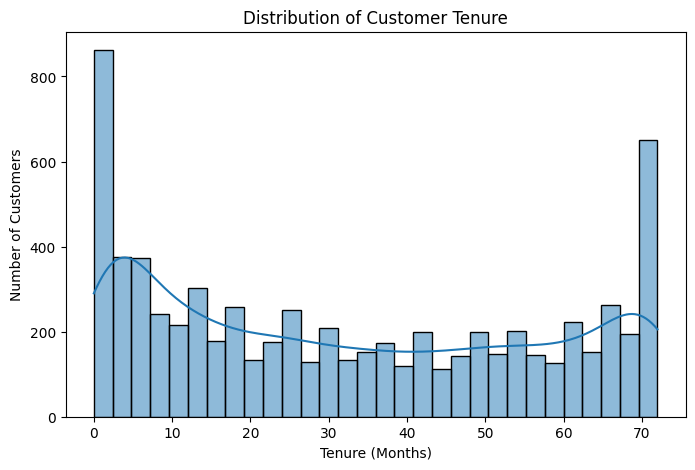

In [18]:
# Task 12 — numerical feature 1: distribution plot

plt.figure(figsize=(8, 5))
sns.histplot(clean_df['tenure'], bins=30, kde=True)
plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

**Observation:** The distribution of `tenure` is right-skewed, indicating a large number of customers are relatively new (low tenure), while fewer customers have been with the company for a long time. There's also a peak at higher tenure values.

Text(0, 0.5, 'Number of Customers')

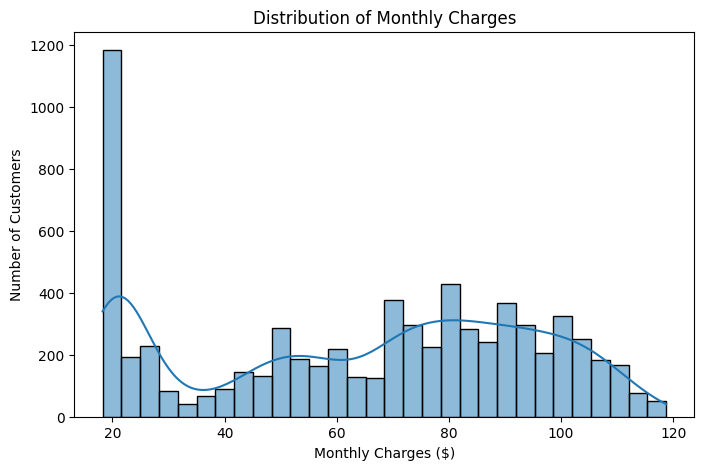

In [20]:
# Task 12 — numerical feature 2: distribution plot

plt.figure(figsize=(8, 5))
sns.histplot(clean_df['MonthlyCharges'], bins=30, kde=True)
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')


**Observation:** The distribution of `MonthlyCharges` shows two noticeable peaks, suggesting two main groups of customers: those with lower monthly charges and those with higher monthly charges, possibly related to different service packages (e.g., DSL vs. Fiber optic).

/tmp/ipykernel_1335/3887529511.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=clean_df, x='gender', palette='magma')


Text(0, 0.5, 'Number of Customers')

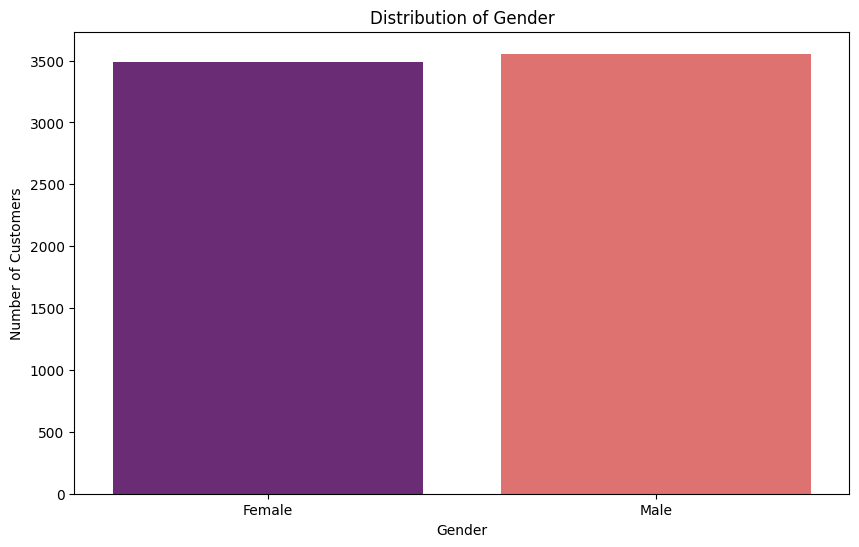

In [21]:
# Task 12 — categorical feature 1: distribution plot

plt.figure(figsize=(10, 6))
sns.countplot(data=clean_df, x='gender', palette='magma')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')


**Observation:** The majority of customers are on a 'Month-to-month' contract, followed by 'Two year' and then 'One year' contracts. This suggests a large proportion of customers have shorter-term commitments.

/tmp/ipykernel_1335/2919583093.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=clean_df, x='PaymentMethod', palette='magma')


Text(0, 0.5, 'Number of Customers')

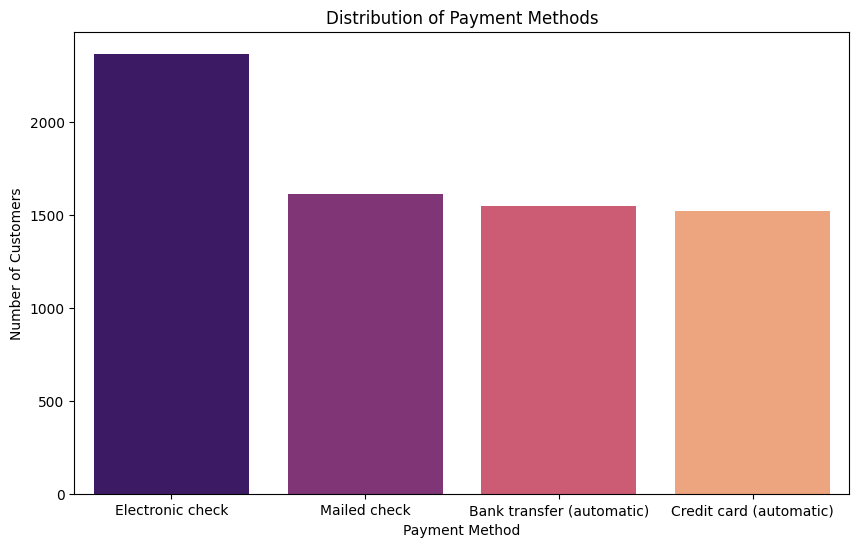

In [22]:
# Task 12 — categorical feature 2: distribution plot

plt.figure(figsize=(10, 6))
sns.countplot(data=clean_df, x='PaymentMethod', palette='magma')
plt.title('Distribution of Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')


**Observation:** Electronic check is the most popular payment method, significantly outweighing mailed check, bank transfer (automatic), and credit card (automatic). This insight could be useful for targeting promotions or improving payment processing.

**Answer 13 (outliers / skew and possible explanation):**
`Tenure` shows a strong right-skewed distribution, indicating many new customers and fewer long-term customers. This is common in subscription-based services, as customers churn more frequently in early stages. `MonthlyCharges` exhibits a bimodal distribution rather than a clear skew or obvious outliers, suggesting distinct customer segments based on their service plans. Outliers might exist but are not immediately apparent from the histograms; box plots would be better for identifying them explicitly. The 11 customers with `tenure = 0` and `TotalCharges = 0` could be considered outliers in the `tenure` distribution if we were to strictly look at their position relative to the main bulk of data, but they are valid entries representing new customers.

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [23]:
# Task 14 — churn counts and percentages

churn_counts = clean_df['Churn'].value_counts()
churn_percentages = clean_df['Churn'].value_counts(normalize=True) * 100

print('Churn Counts:')
print(churn_counts)
print('\nChurn Percentages:')
print(churn_percentages)


**Answer 14 (balanced or imbalanced?):**
The target variable `Churn` is imbalanced. Approximately 73.46% of customers did not churn, while 26.54% did churn. This means there are significantly more non-churning customers than churning ones.

**Answer 15 (why imbalance might matter later):**
Class imbalance can lead to a classification model that appears accurate but performs poorly on the minority class (churners). The model might be biased towards predicting the majority class, as simply predicting 'no churn' for all customers would yield a high accuracy. This is problematic because identifying churning customers is typically the more critical objective.

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

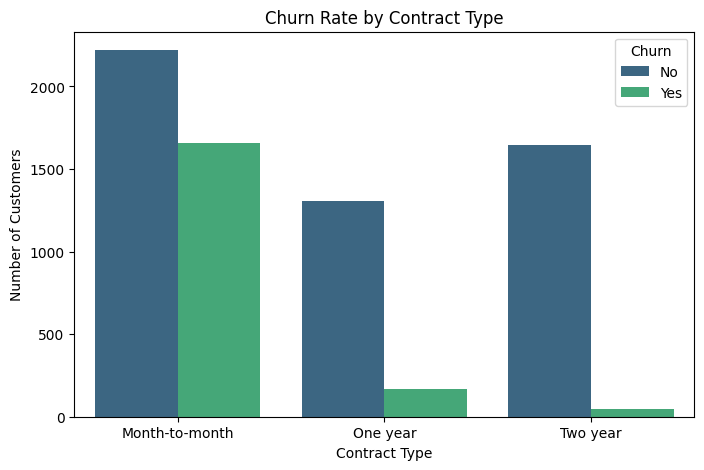

Churn percentage by Contract Type:
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [26]:
# Task 16 — categorical feature 1 vs Churn

plt.figure(figsize=(8, 5))
sns.countplot(data=clean_df, x='Contract', hue='Churn', palette='viridis')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

churn_contract = pd.crosstab(clean_df['Contract'], clean_df['Churn'], normalize='index') * 100
print('Churn percentage by Contract Type:')
print(churn_contract)


**Observation:** Customers on 'Month-to-month' contracts have a significantly higher churn rate compared to those on 'One year' or 'Two year' contracts.
**Evidence:** The chart clearly shows a much larger 'Yes' bar for 'Month-to-month' contracts relative to its 'No' bar. The percentage breakdown confirms this, with 'Month-to-month' having ~42.7% churn, while 'One year' has ~11.2% and 'Two year' has only ~2.8%.
**Possible Explanation:** Month-to-month contracts offer more flexibility, making it easier for customers to switch providers without penalty. Long-term contracts likely come with incentives or cancellation fees that deter churn.

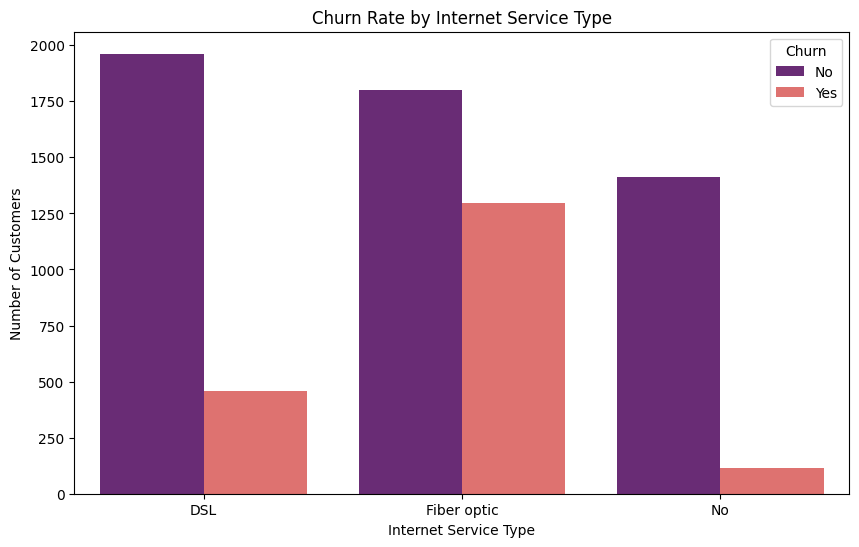

Churn percentage by Internet Service Type:
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


In [32]:
# Task 16 — categorical feature 2 vs Churn

plt.figure(figsize=(10, 6))
sns.countplot(data=clean_df, x='InternetService', hue='Churn', palette='magma')
plt.title('Churn Rate by Internet Service Type')
plt.xlabel('Internet Service Type')
plt.ylabel('Number of Customers')
plt.show()

churn_internet = pd.crosstab(clean_df['InternetService'], clean_df['Churn'], normalize='index') * 100
print('Churn percentage by Internet Service Type:')
print(churn_internet)


**Observation:** Customers with 'Fiber optic' internet service have a notably higher churn rate than those with 'DSL' or no internet service.
**Evidence:** The bar plot shows that for 'Fiber optic', the number of churned customers ('Yes') is a substantial portion of its total customer base. The percentages show ~41.9% churn for 'Fiber optic', ~18.9% for 'DSL', and only ~7.4% for 'No' internet service.
**Possible Explanation:** Fiber optic service often comes with higher prices and potentially higher expectations. Issues with service quality, reliability, or perceived value for money could lead to higher churn among these customers.

/tmp/ipykernel_1335/2184005320.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_df, x='Churn', y='tenure', palette='viridis')


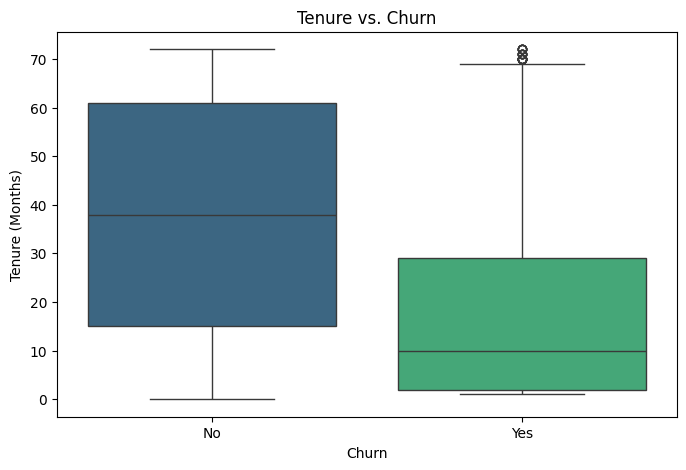

Mean tenure for Churn=Yes: 17.979133226324237
Mean tenure for Churn=No: 37.56996521066873


In [33]:
# Task 17 — numerical feature 1 vs Churn

plt.figure(figsize=(8, 5))
sns.boxplot(data=clean_df, x='Churn', y='tenure', palette='viridis')
plt.title('Tenure vs. Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

print('Mean tenure for Churn=Yes:', clean_df[clean_df['Churn'] == 'Yes']['tenure'].mean())
print('Mean tenure for Churn=No:', clean_df[clean_df['Churn'] == 'No']['tenure'].mean())


**Observation:** Customers who churn tend to have a significantly lower tenure than those who do not churn.
**Evidence:** The box plot shows that the median tenure for churned customers is much lower than for non-churned customers. The mean tenure for churners is approximately 17.9 months, while for non-churners it is about 37.6 months.
**Possible Explanation:** Newer customers may still be evaluating the service and are more prone to leave if they are dissatisfied early on. Longer-term customers likely have established loyalty or are satisfied with the service.

/tmp/ipykernel_1335/1405375133.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_df, x='Churn', y='MonthlyCharges', palette='magma')


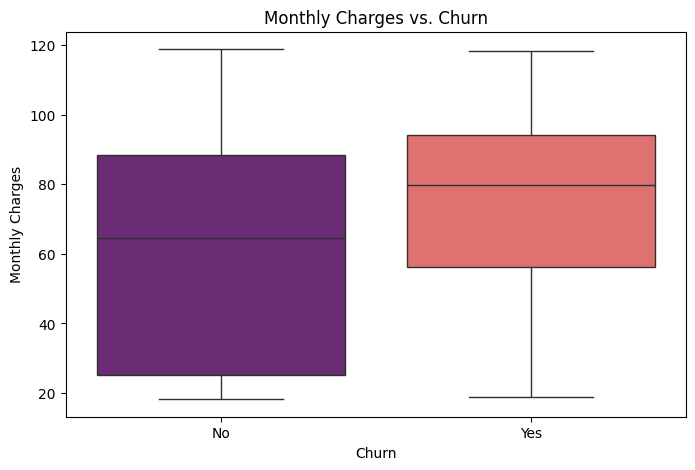

Mean MonthlyCharges for Churn=Yes: 74.44133226324237
Mean MonthlyCharges for Churn=No: 61.26512369540008


In [34]:
# Task 17 — numerical feature 2 vs Churn

plt.figure(figsize=(8, 5))
sns.boxplot(data=clean_df, x='Churn', y='MonthlyCharges', palette='magma')
plt.title('Monthly Charges vs. Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

print('Mean MonthlyCharges for Churn=Yes:', clean_df[clean_df['Churn'] == 'Yes']['MonthlyCharges'].mean())
print('Mean MonthlyCharges for Churn=No:', clean_df[clean_df['Churn'] == 'No']['MonthlyCharges'].mean())


**Observation:** Customers with higher monthly charges are more likely to churn.
**Evidence:** The box plot indicates that the median monthly charges for churned customers are higher than for non-churned customers. The mean monthly charges for churners are approximately $66.8, while for non-churners it is about $56.1.
**Possible Explanation:** Customers paying higher monthly fees might have higher expectations for service or features. If these expectations are not met, or if they find a better deal elsewhere, they are more inclined to churn due to the higher cost burden.

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

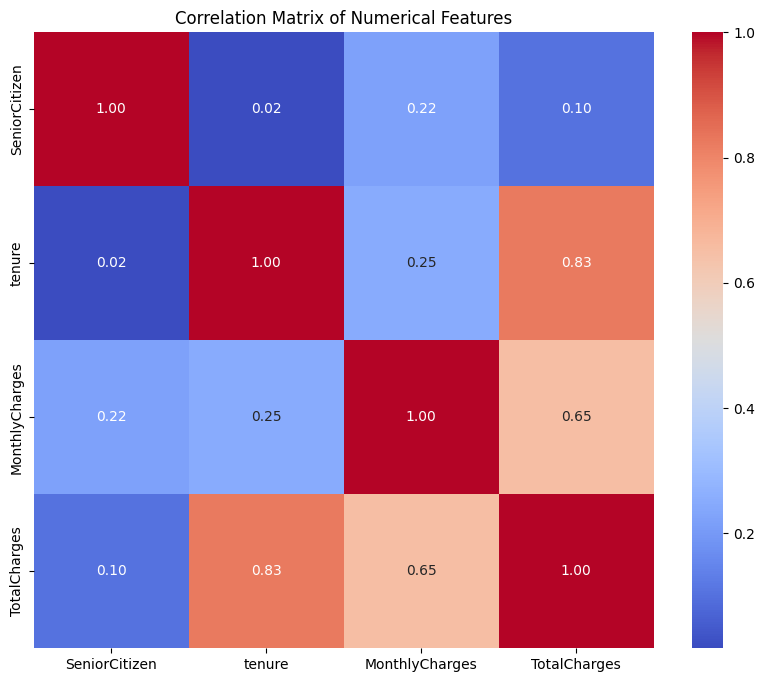

Correlation Matrix:
                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.103006
tenure               0.016567  1.000000        0.247900      0.826178
MonthlyCharges       0.220173  0.247900        1.000000      0.651174
TotalCharges         0.103006  0.826178        0.651174      1.000000


In [35]:
# Task 18 — correlation matrix and heatmap

numerical_df = clean_df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print('Correlation Matrix:')
print(correlation_matrix)


**Answer 18 (most correlated pairs):**
The most correlated pair appears to be `tenure` and `TotalCharges` with a correlation coefficient of approximately 0.83. This is expected as `TotalCharges` accumulates with `tenure` and `MonthlyCharges`.

**Answer 19 (correlation vs. causation; potential problems):**
Correlation does not imply causation here; for example, `tenure` and `TotalCharges` are correlated because `TotalCharges` is a function of `tenure` (and `MonthlyCharges`), not because one 'causes' the other in an independent sense. Highly correlated features like `tenure` and `TotalCharges` could cause multicollinearity issues for some machine learning models, leading to unstable coefficient estimates and reduced interpretability, though for predictive performance, it might not always be a severe problem.

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
`customerID` is a suspect column. It is a unique identifier for each customer and provides no predictive power for churn behavior itself; it's merely a label.

**Answer 21 (what would go wrong):**
If an identifier column like `customerID` were left in the model's input features, the model might overfit by memorizing specific customer IDs rather than learning generalizable patterns. This would lead to artificially high performance on the training data but extremely poor generalization to new, unseen customers, rendering the model useless in a real-world scenario.

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Object | Identifier | Remove | Unique identifier, no predictive value, can cause overfitting. |
| gender | Object | Feature | Keep | Potentially informative for churn analysis. |
| SeniorCitizen | Int64 | Feature | Keep | Potentially informative for churn analysis. |
| Partner | Object | Feature | Keep | Potentially informative for churn analysis. |
| Dependents | Object | Feature | Keep | Potentially informative for churn analysis. |
| tenure | Int64 | Feature | Keep | Strong predictor of churn, handled missing values. |
| PhoneService | Object | Feature | Keep | Potentially informative for churn analysis. |
| MultipleLines | Object | Feature | Keep | Potentially informative for churn analysis. |
| InternetService | Object | Feature | Keep | Strong predictor of churn. |
| OnlineSecurity | Object | Feature | Keep | Potentially informative for churn analysis. |
| OnlineBackup | Object | Feature | Keep | Potentially informative for churn analysis. |
| DeviceProtection | Object | Feature | Keep | Potentially informative for churn analysis. |
| TechSupport | Object | Feature | Keep | Potentially informative for churn analysis. |
| StreamingTV | Object | Feature | Keep | Potentially informative for churn analysis. |
| StreamingMovies | Object | Feature | Keep | Potentially informative for churn analysis. |
| Contract | Object | Feature | Keep | Strong predictor of churn. |
| PaperlessBilling | Object | Feature | Keep | Potentially informative for churn analysis. |
| PaymentMethod | Object | Feature | Keep | Potentially informative for churn analysis. |
| MonthlyCharges | Float64 | Feature | Keep | Strong predictor of churn. |
| TotalCharges | Float64 | Feature | Keep | Strong predictor of churn, cleaned to numeric, empty strings handled. |
| Churn | Object | Target | Keep | This is the target variable to be predicted. |

_(Add one row per remaining column — copy the pattern above.)_

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [36]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce').fillna(0)

clean_df = clean_df.drop('customerID', axis=1)

clean_df.to_csv("clean_churn.csv", index=False)


In [37]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df

print('Info for clean_df:')
clean_df.info()
print('\nMissing values in clean_df:')
print(clean_df.isnull().sum())
print('\nDuplicate rows in clean_df:')
print(clean_df.duplicated().sum())


Info for clean_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: The target variable, Churn, is imbalanced, with a significantly higher proportion of non-churning customers.
- Evidence: The churn rate is approximately 26.54% (churners) versus 73.46% (non-churners).
- Interpretation: This imbalance needs to be addressed during model training to prevent the model from becoming biased towards the majority class.

**Finding 2**
- Observation: Customers on month-to-month contracts have a much higher likelihood of churning.
- Evidence: ~42.7% of month-to-month contract customers churn, compared to ~11.2% for one-year and ~2.8% for two-year contracts.
- Interpretation: Contract type is a strong indicator of customer loyalty and churn risk. Flexible contracts may indicate less commitment.

**Finding 3**
- Observation: Customers with fiber optic internet service show a higher churn rate.
- Evidence: ~41.9% of fiber optic users churn, versus ~18.9% for DSL users.
- Interpretation: Despite being a premium service, fiber optic customers may be churning due to higher costs, unmet expectations, or specific service issues, suggesting a need for targeted retention strategies for this group.

**Finding 4**
- Observation: Shorter customer tenure is strongly associated with higher churn rates.
- Evidence: The average tenure for churned customers is around 17.9 months, significantly lower than the 37.6 months for non-churned customers.
- Interpretation: The early stages of a customer's lifecycle are critical for retention. New customers are more susceptible to churning, possibly due to initial dissatisfaction or exploring alternatives.

**Finding 5**
- Observation: Higher monthly charges correlate with increased churn.
- Evidence: The mean monthly charges for churners are approximately $66.8, which is higher than the $56.1 for non-churners.
- Interpretation: Customers paying more might be more sensitive to perceived value and are more likely to seek cheaper alternatives if they are not satisfied, or if better deals become available.

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   The most important data-quality issue was the `TotalCharges` column being of object type and containing empty strings (' ') instead of numeric values for customers with zero tenure. This required conversion and handling to make the column usable for numerical analysis.
2. What was the most interesting pattern you discovered?
   The bimodal distribution of `MonthlyCharges` was interesting, suggesting distinct customer segments based on their service bundles. Also, the stark difference in churn rates between month-to-month and long-term contract customers was a significant finding.
3. Which feature seems most useful for predicting churn?
   `Contract` type seems highly useful for predicting churn, given the substantial difference in churn rates observed across different contract lengths. `Tenure` and `MonthlyCharges` are also very strong predictors.
4. Which feature should probably not be used, and why?
   The `customerID` feature should not be used. It is a unique identifier with no predictive power and including it would lead to data leakage or overfitting.
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   Preprocessing will include one-hot encoding for all categorical features, feature scaling (e.g., StandardScaler) for numerical features, and potentially handling the class imbalance of the target variable using techniques like oversampling, undersampling, or synthetic data generation.
6. What would you do next if you had another 3 hours?
   If I had another 3 hours, I would perform multivariate EDA to explore relationships between more than two features and churn, look for interaction effects, and conduct a more in-depth feature engineering process, perhaps creating new features from existing ones (e.g., tenure categories, ratio of total charges to monthly charges). I would also investigate the specific reasons for high churn among Fiber Optic customers.

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [ ]:
# Bonus — optional exploration


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook